# Test 3: Allen-Cahn Baseline Comparison

This notebook uses the same restored Allen-Cahn latent KSWGD setup and compares the final latent samples with baseline particle methods.

In [1]:
from dataclasses import replace
import random
import time

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from plotting_utils import setup_plot_style, ensure_dir
setup_plot_style(scale=1.5)
RANDOM_SEED = 5
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

from systems import (
    AllenCahnConfig, StochasticAllenCahn2D, sample_ac_initial_fields,
    train_ac_autoencoder, encode_ac_fields, decode_ac_latent,
)
from kswgd import train_sdmd_solver, build_target_kernel_torch, run_latent_kswgd_with_spectrum
from baseline import kde_score, mmd_rbf, sliced_wasserstein, run_matrix_svgd, run_svgd, run_ula
from experiment_plots import plot_ac_field_grid, plot_ac_histogram_timeline, plot_ac_method_timeline_overlay, summarize_fields

NOISE_CONFIGS = {
    1.4142: replace(
        AllenCahnConfig(), N=128, sigma=1.4142, n_snapshots=900, burnin=25,
        dt=2e-5, epsilon=0.01, diffusion=0.001, latent_dim=16,
        n_particles=300, n_iter=1500, step_size=0.08, seed=RANDOM_SEED,
    ),
    0.1: replace(
        AllenCahnConfig(), N=128, sigma=0.1, n_snapshots=251, burnin=50,
        dt=1e-5, epsilon=0.02, diffusion=0.001, latent_dim=8,
        n_particles=100, n_iter=500, step_size=0.05, seed=RANDOM_SEED,
    ),
}
AE_EPOCHS_BY_SIGMA = {1.4142: 120, 0.1: 160}
AE_TARGET_REPEATS_BY_SIGMA = {1.4142: 1, 0.1: 3}
SNAPSHOT_STEPS_BY_SIGMA = {
    1.4142: [0, 10, 20, 30, 50, 100, 750, 1500],
    0.1: [0, 10, 20, 30, 50, 100, 250, 500],
}
TARGET_INITIAL_MOVEMENT_BY_SIGMA = {1.4142: 0.02, 0.1: 0.04}
MAX_PARTICLE_STEP_BY_SIGMA = {1.4142: 0.05, 0.1: 0.1}
KERNEL_INIT_TARGET_SCALE = 0.2
KERNEL_EPSILON_OVERRIDE = None
SDMD_EPOCHS = 6
SDMD_BATCH_SIZE = 256
SDMD_LR = 1e-5
N_PSI_TRAIN = 64
SDMD_LAYER_SIZES = [64, 64]
SDMD_REG = 0.1
TRAIN_FRACTION = 0.7
K_MODES_FIXED = 60
EIG_THRESHOLD = 1e-3
N_SKIP = 1
RECORD_INTERVAL = 100
ensure_dir('figures/allen_cahn')
for sigma, cfg in NOISE_CONFIGS.items():
    print(f'sigma={sigma:g}: {cfg}')

sigma=1.4142: AllenCahnConfig(sigma=1.4142, N=128, n_snapshots=900, burnin=25, dt=2e-05, epsilon=0.01, diffusion=0.001, seed=5, latent_dim=16, n_particles=300, n_iter=1500, step_size=0.08)
sigma=0.1: AllenCahnConfig(sigma=0.1, N=128, n_snapshots=251, burnin=50, dt=1e-05, epsilon=0.02, diffusion=0.001, seed=5, latent_dim=8, n_particles=100, n_iter=500, step_size=0.05)


In [2]:
results = {}
for sigma, cfg in NOISE_CONFIGS.items():
    start = time.time()
    print('\n' + '=' * 72)
    print(f'Allen-Cahn noise sigma={sigma:g}')
    print('=' * 72)
    steps = SNAPSHOT_STEPS_BY_SIGMA[sigma]

    fields = StochasticAllenCahn2D(cfg).simulate().astype(np.float32)
    fields_tar = fields[:-1]
    fields_next = fields[1:]
    pair_dt = cfg.dt
    init_pool = sample_ac_initial_fields(
        max(cfg.n_particles, 300), N=cfg.N, mode='uniform_fields',
        low=-0.5, high=0.5, seed=cfg.seed + 101,
    )
    print(f'fields: {fields.shape}; target pairs: {fields_tar.shape} -> {fields_next.shape}; init pool: {init_pool.shape}')

    ae_training_parts = [fields] * AE_TARGET_REPEATS_BY_SIGMA[sigma]
    ae_training_parts.append(init_pool)
    ae_training_fields = np.concatenate(ae_training_parts, axis=0)
    ae, data_min, data_max, device = train_ac_autoencoder(
        ae_training_fields, latent_dim=cfg.latent_dim,
        n_epochs=AE_EPOCHS_BY_SIGMA[sigma], batch_size=32,
        lr=1e-3, seed=cfg.seed, verbose=True,
    )

    Z_all_raw = encode_ac_fields(ae, fields, data_min, data_max, device)
    Z_tar_raw, Z_next_raw = Z_all_raw[:-1].copy(), Z_all_raw[1:].copy()
    Z_init_pool_raw = encode_ac_fields(ae, init_pool, data_min, data_max, device)
    latent_ref = np.concatenate([Z_tar_raw, Z_next_raw, Z_init_pool_raw], axis=0)
    latent_shift = latent_ref.mean(axis=0)
    latent_scale = latent_ref.std(axis=0) + 1e-8
    to_scaled = lambda z, shift=latent_shift, scale=latent_scale: (z - shift) / scale
    from_scaled = lambda z, shift=latent_shift, scale=latent_scale: z * scale + shift
    def decode_scaled(z, _ae=ae, _cfg=cfg, _min=data_min, _max=data_max, _device=device, _from=from_scaled):
        return decode_ac_latent(_ae, _from(z), _cfg.N, _min, _max, _device)

    Z_tar = to_scaled(Z_tar_raw)
    Z_next = to_scaled(Z_next_raw)
    Z_init_pool = to_scaled(Z_init_pool_raw)
    rng = np.random.default_rng(cfg.seed)
    init_indices = rng.choice(len(Z_init_pool), size=cfg.n_particles, replace=len(Z_init_pool) < cfg.n_particles)
    Z_init = Z_init_pool[init_indices].copy()
    init_reference = init_pool[init_indices].copy()

    solver = train_sdmd_solver(
        Z_tar, Z_next, input_size=cfg.latent_dim, layer_sizes=SDMD_LAYER_SIZES,
        n_psi_train=N_PSI_TRAIN, target_dim=cfg.latent_dim, delta_t=pair_dt,
        reg=SDMD_REG, epochs=SDMD_EPOCHS, batch_size=SDMD_BATCH_SIZE,
        lr=SDMD_LR, fnn_batch_size=64,
        checkpoint_file=f'checkpoints/ac_latent_sigma_{sigma:g}_koopman.torch',
        fnn_checkpoint_file=f'checkpoints/ac_latent_sigma_{sigma:g}_fnn.torch',
        a_b_file=f'checkpoints/ac_latent_sigma_{sigma:g}_ab.jbl',
        train_fraction=TRAIN_FRACTION,
    )
    eigvals = np.real(solver.eigenvalues.T).reshape(-1)
    lambda_gen = (eigvals - 1.0) / pair_dt
    eigfuncs_on_target = np.real(solver.eigenfunctions(Z_tar))

    target_kernel = build_target_kernel_torch(
        Z_tar, c_epsilon=0.5, X_reference=Z_init,
        reference_scale=KERNEL_INIT_TARGET_SCALE,
        epsilon_override=KERNEL_EPSILON_OVERRIDE,
    )
    result = run_latent_kswgd_with_spectrum(
        method_name='KSWGD', Z_init=Z_init, Z_target=Z_tar,
        target_kernel=target_kernel, eigvecs_on_target=eigfuncs_on_target,
        lambda_gen_full_values=lambda_gen, eigvals_for_mode_selection=eigvals,
        fixed_mode_count=K_MODES_FIXED, eig_threshold_value=EIG_THRESHOLD,
        n_skip_modes=N_SKIP, n_iter=cfg.n_iter, step_size=cfg.step_size,
        record_every=RECORD_INTERVAL, snapshot_steps=steps,
        adaptive_step=True,
        target_initial_movement=TARGET_INITIAL_MOVEMENT_BY_SIGMA[sigma],
        max_step_multiplier=1e13,
        max_particle_step=MAX_PARTICLE_STEP_BY_SIGMA[sigma],
        progress=True,
    )
    decoded = {step: decode_scaled(z) for step, z in result.snapshots.items()}
    n_compare = min(cfg.n_particles, len(fields_tar))
    ae_recon = decode_scaled(Z_tar[:n_compare])
    bw = max(float(target_kernel['epsilon']), 1e-8)
    score_fn = lambda X, Zref=Z_tar, bw=bw: kde_score(X, Zref, bandwidth=bw)
    ula = run_ula(Z_init, score_fn=score_fn, n_iter=cfg.n_iter, step_size=0.01, noise_scale=0.12, snapshot_steps=steps, seed=cfg.seed + 1, max_step_norm=0.08)
    svgd = run_svgd(Z_init, score_fn=score_fn, n_iter=cfg.n_iter, step_size=0.012, snapshot_steps=steps, max_step_norm=0.08)
    msvgd = run_matrix_svgd(Z_init, score_fn=score_fn, n_iter=cfg.n_iter, step_size=0.014, snapshot_steps=steps, reg=0.05, max_step_norm=0.08)
    method_results = {'KSWGD': result, 'ULA': ula, 'SVGD': svgd, 'Matrix SVGD': msvgd}
    decoded_final = {name: decode_scaled(res.final) for name, res in method_results.items()}
    decoded_by_method_step = {name: {step: decode_scaled(z) for step, z in res.snapshots.items()} for name, res in method_results.items()}
    metrics = {name: {'MMD': mmd_rbf(Z_tar, res.final), 'SW': sliced_wasserstein(Z_tar, res.final, seed=cfg.seed)} for name, res in method_results.items()}
    results[sigma] = {
        'cfg': cfg, 'fields': fields, 'target_fields': fields_tar,
        'init_reference': init_reference, 'ae_recon': ae_recon,
        'Z_tar': Z_tar, 'Z_init': Z_init, 'result': result,
        'decoded': decoded, 'steps': steps, 'decode': decode_scaled,
        'method_results': method_results, 'decoded_final': decoded_final,
        'decoded_by_method_step': decoded_by_method_step, 'metrics': metrics,
    }
    for name, row in metrics.items():
        print(f"{name:12s}: latent MMD={row['MMD']:.4f}, latent SW={row['SW']:.4f}")
    print(summarize_fields('target', fields_tar))
    print(summarize_fields('AE recon', ae_recon))
    print(summarize_fields('initial', init_reference))
    print(summarize_fields('final', decoded[cfg.n_iter]))
    print(f'Finished sigma={sigma:g} in {(time.time() - start) / 60:.2f} min')


Allen-Cahn noise sigma=1.4142


fields: (900, 128, 128); target pairs: (899, 128, 128) -> (899, 128, 128); init pool: (300, 128, 128)


AE epoch 1/120: loss=7.629136e-02


AE epoch 25/120: loss=1.956168e-02


AE epoch 50/120: loss=1.799731e-02


...

Epoch: 1 	Training Loss: 0.000006 val loss: 0.000000
Saving model, val loss improved from 0.000000 to 0.000000
Epoch: 2 	Training Loss: 0.000006 val loss: 0.000000
Saving model, val loss improved from 0.000000 to 0.000000
EarlyStopping counter: 1 out of 7
Epoch 6 time: 0.52 seconds
KSWGD: particles=100, latent_dim=8, modes=60, epsilon=7.316571e+00
initial K mean/max=1.480e-03/6.402e-03; effective step=4.379e+03


KSWGD: step 83/500, mean step norm=2.820e-02
KSWGD: step 166/500, mean step norm=4.413e-03


KSWGD: step 249/500, mean step norm=7.337e-04
KSWGD: step 332/500, mean step norm=1.256e-04


KSWGD: step 415/500, mean step norm=2.160e-05
KSWGD: step 498/500, mean step norm=3.720e-06
KSWGD: step 500/500, mean step norm=3.566e-06


KSWGD       : latent MMD=1.1009, latent SW=0.3819
ULA         : latent MMD=0.8995, latent SW=1.0946
SVGD        : latent MMD=0.8930, latent SW=1.9875
Matrix SVGD : latent MMD=0.8838, latent SW=1.9748
target: mean=-0.004, std=0.926, frac(|u|>0.8)=87.12%
AE recon: mean=-0.005, std=1.004, frac(|u|>0.8)=100.00%
initial: mean=+0.000, std=0.289, frac(|u|>0.8)=0.00%
final: mean=-0.005, std=1.004, frac(|u|>0.8)=100.00%
Finished sigma=0.1 in 0.55 min


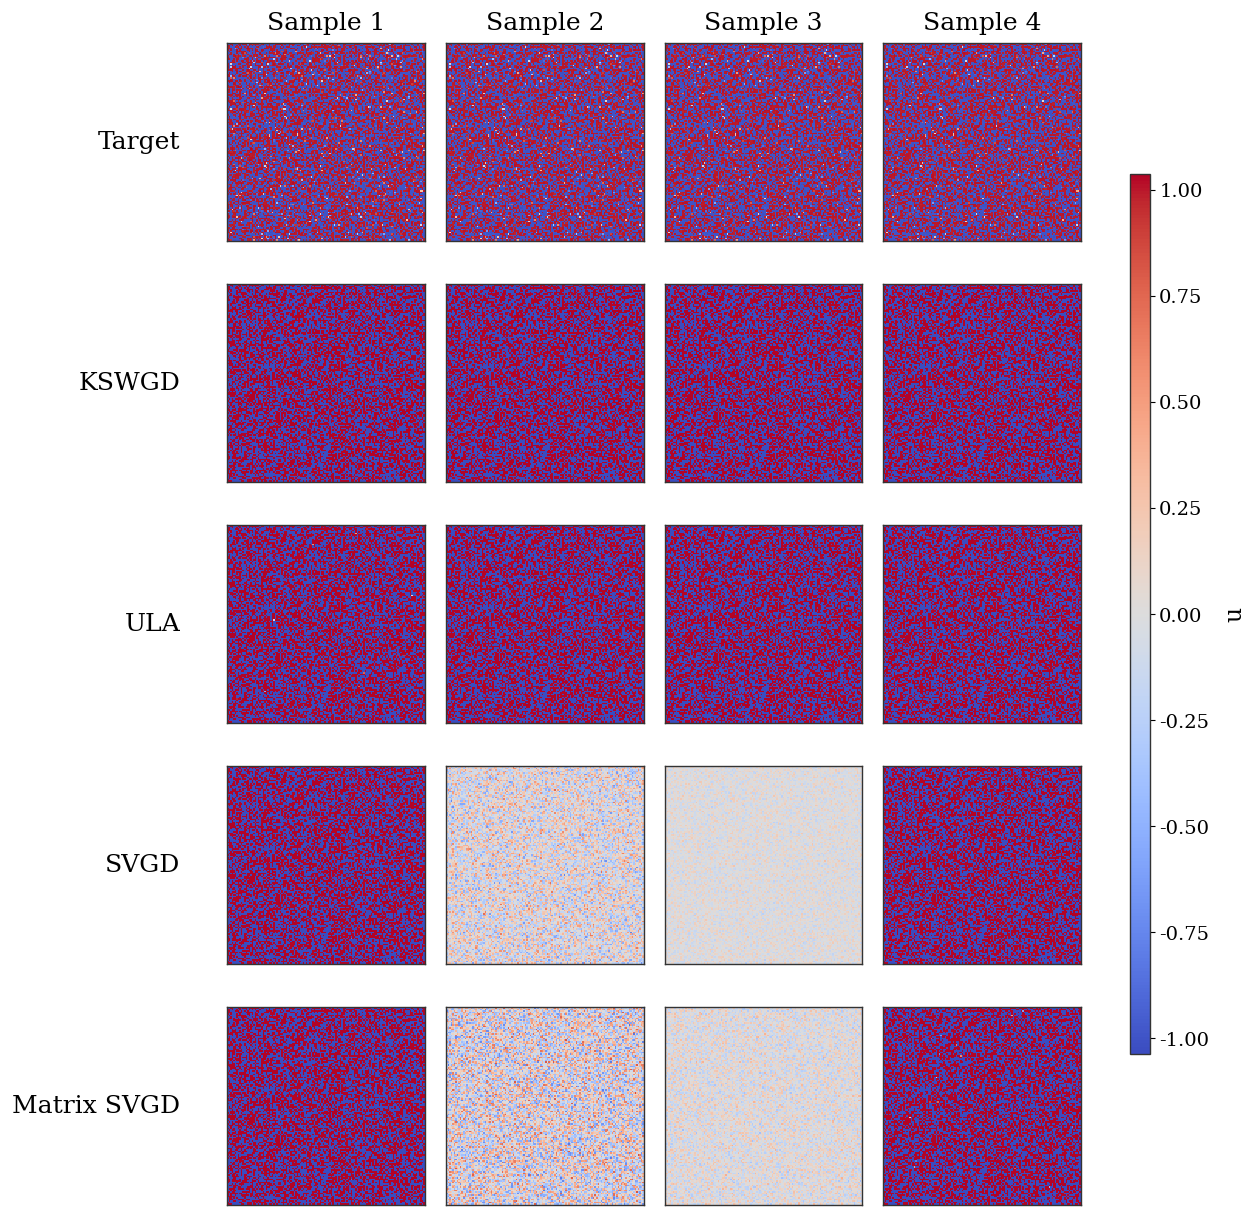

Caption: Decoded Allen-Cahn field samples for KSWGD and baselines at noise sigma=1.4142.
Saved: figures\allen_cahn\test_3_allen_cahn_baseline_sigma_1.4142_fields.png and figures\allen_cahn\test_3_allen_cahn_baseline_sigma_1.4142_fields.pdf


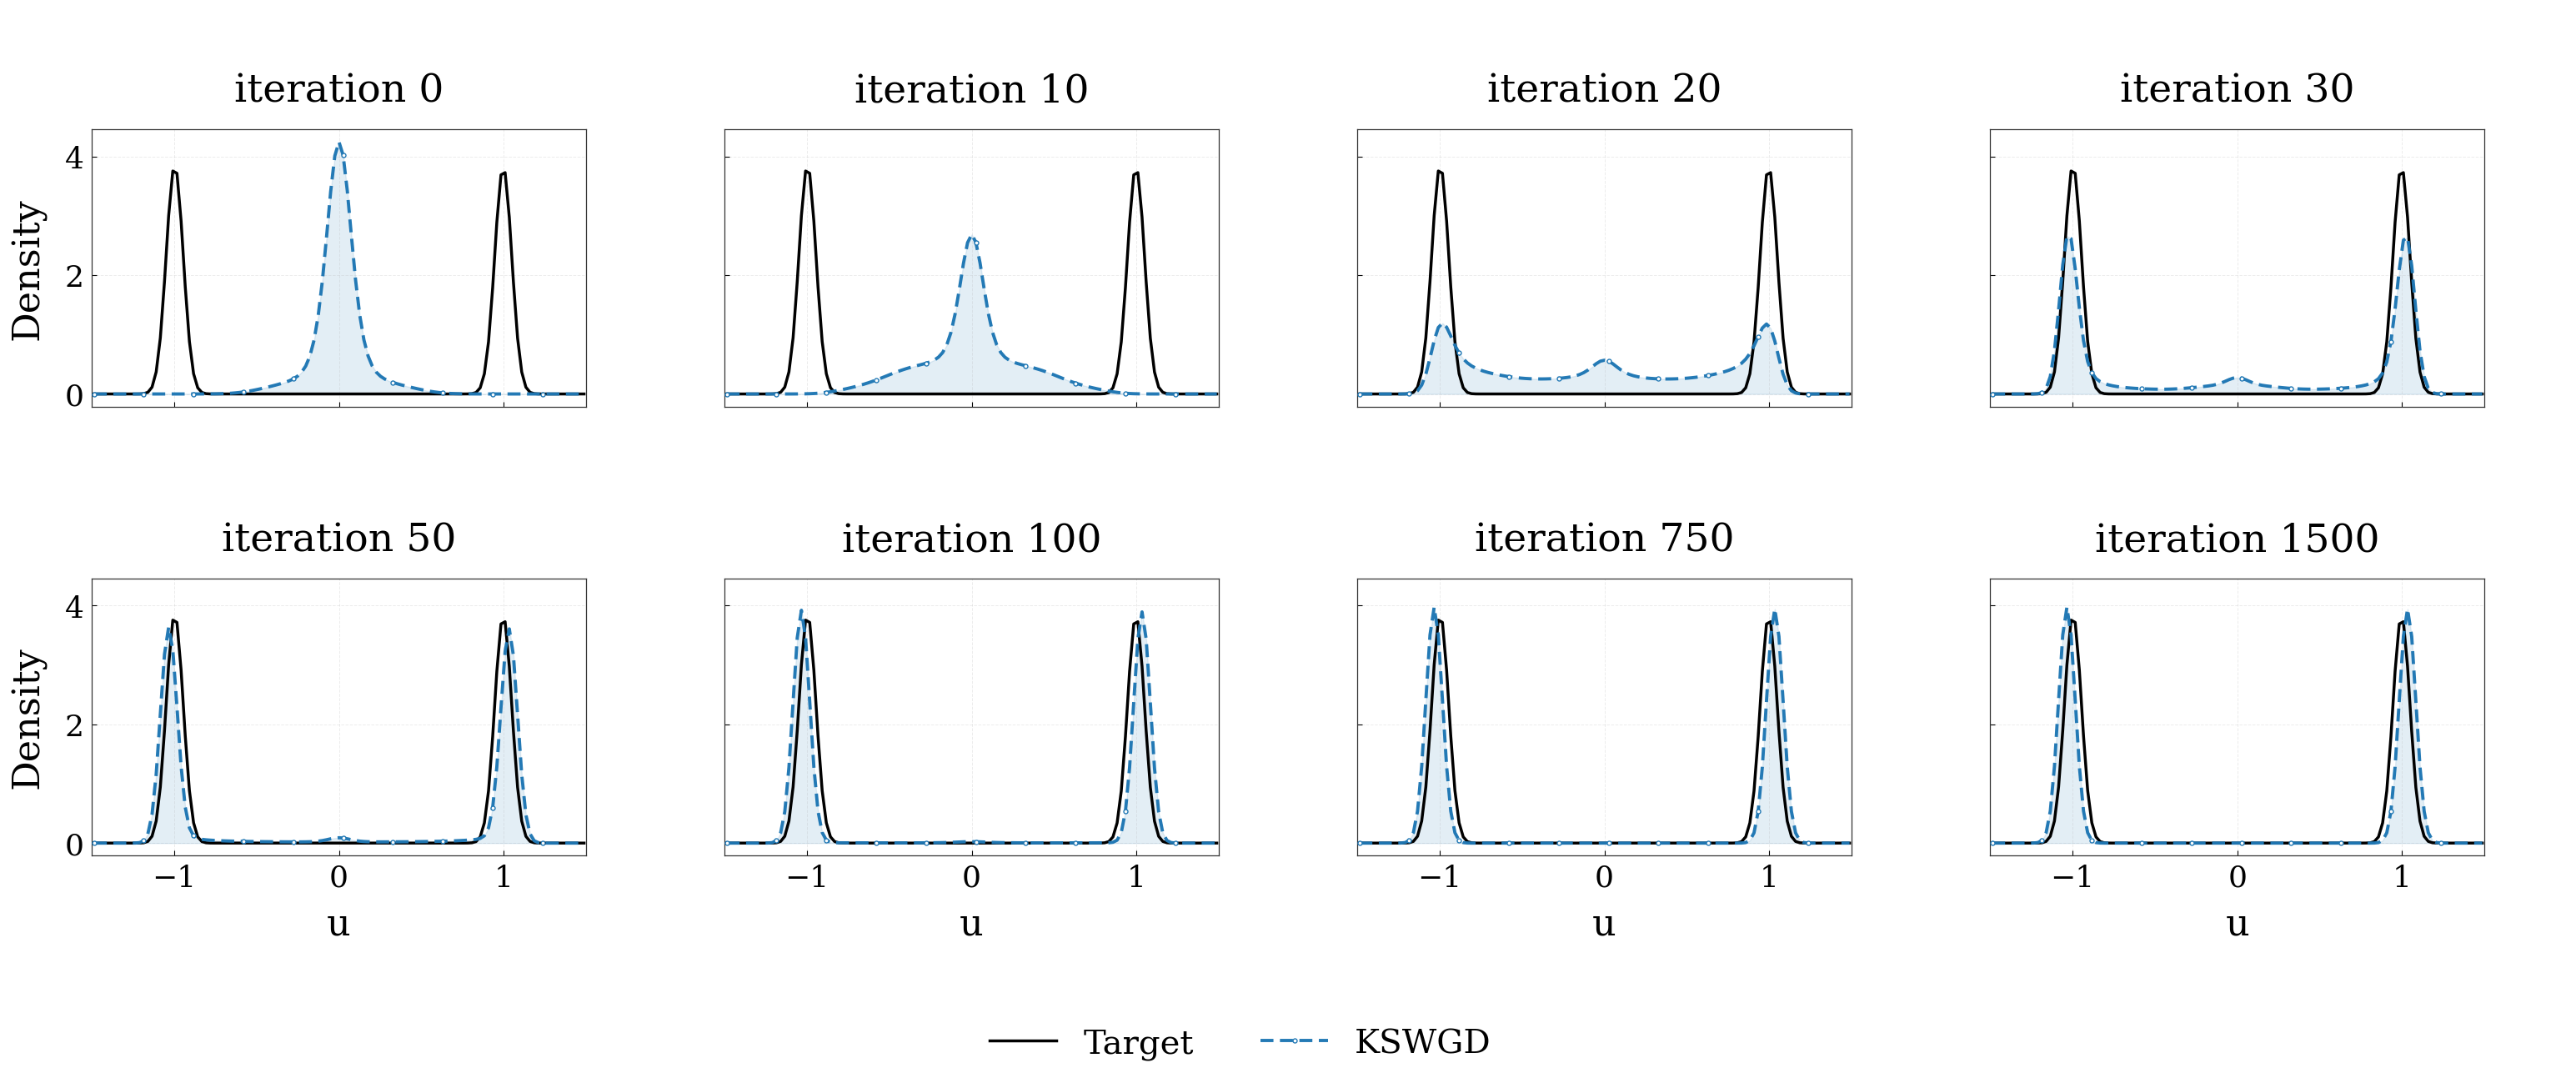

Caption: Pixel-value distributions over iterations for KSWGD at Allen-Cahn noise sigma=1.4142.
Saved: figures\allen_cahn\test_3_allen_cahn_baseline_sigma_1.4142_kswgd_timeline.png and figures\allen_cahn\test_3_allen_cahn_baseline_sigma_1.4142_kswgd_timeline.pdf


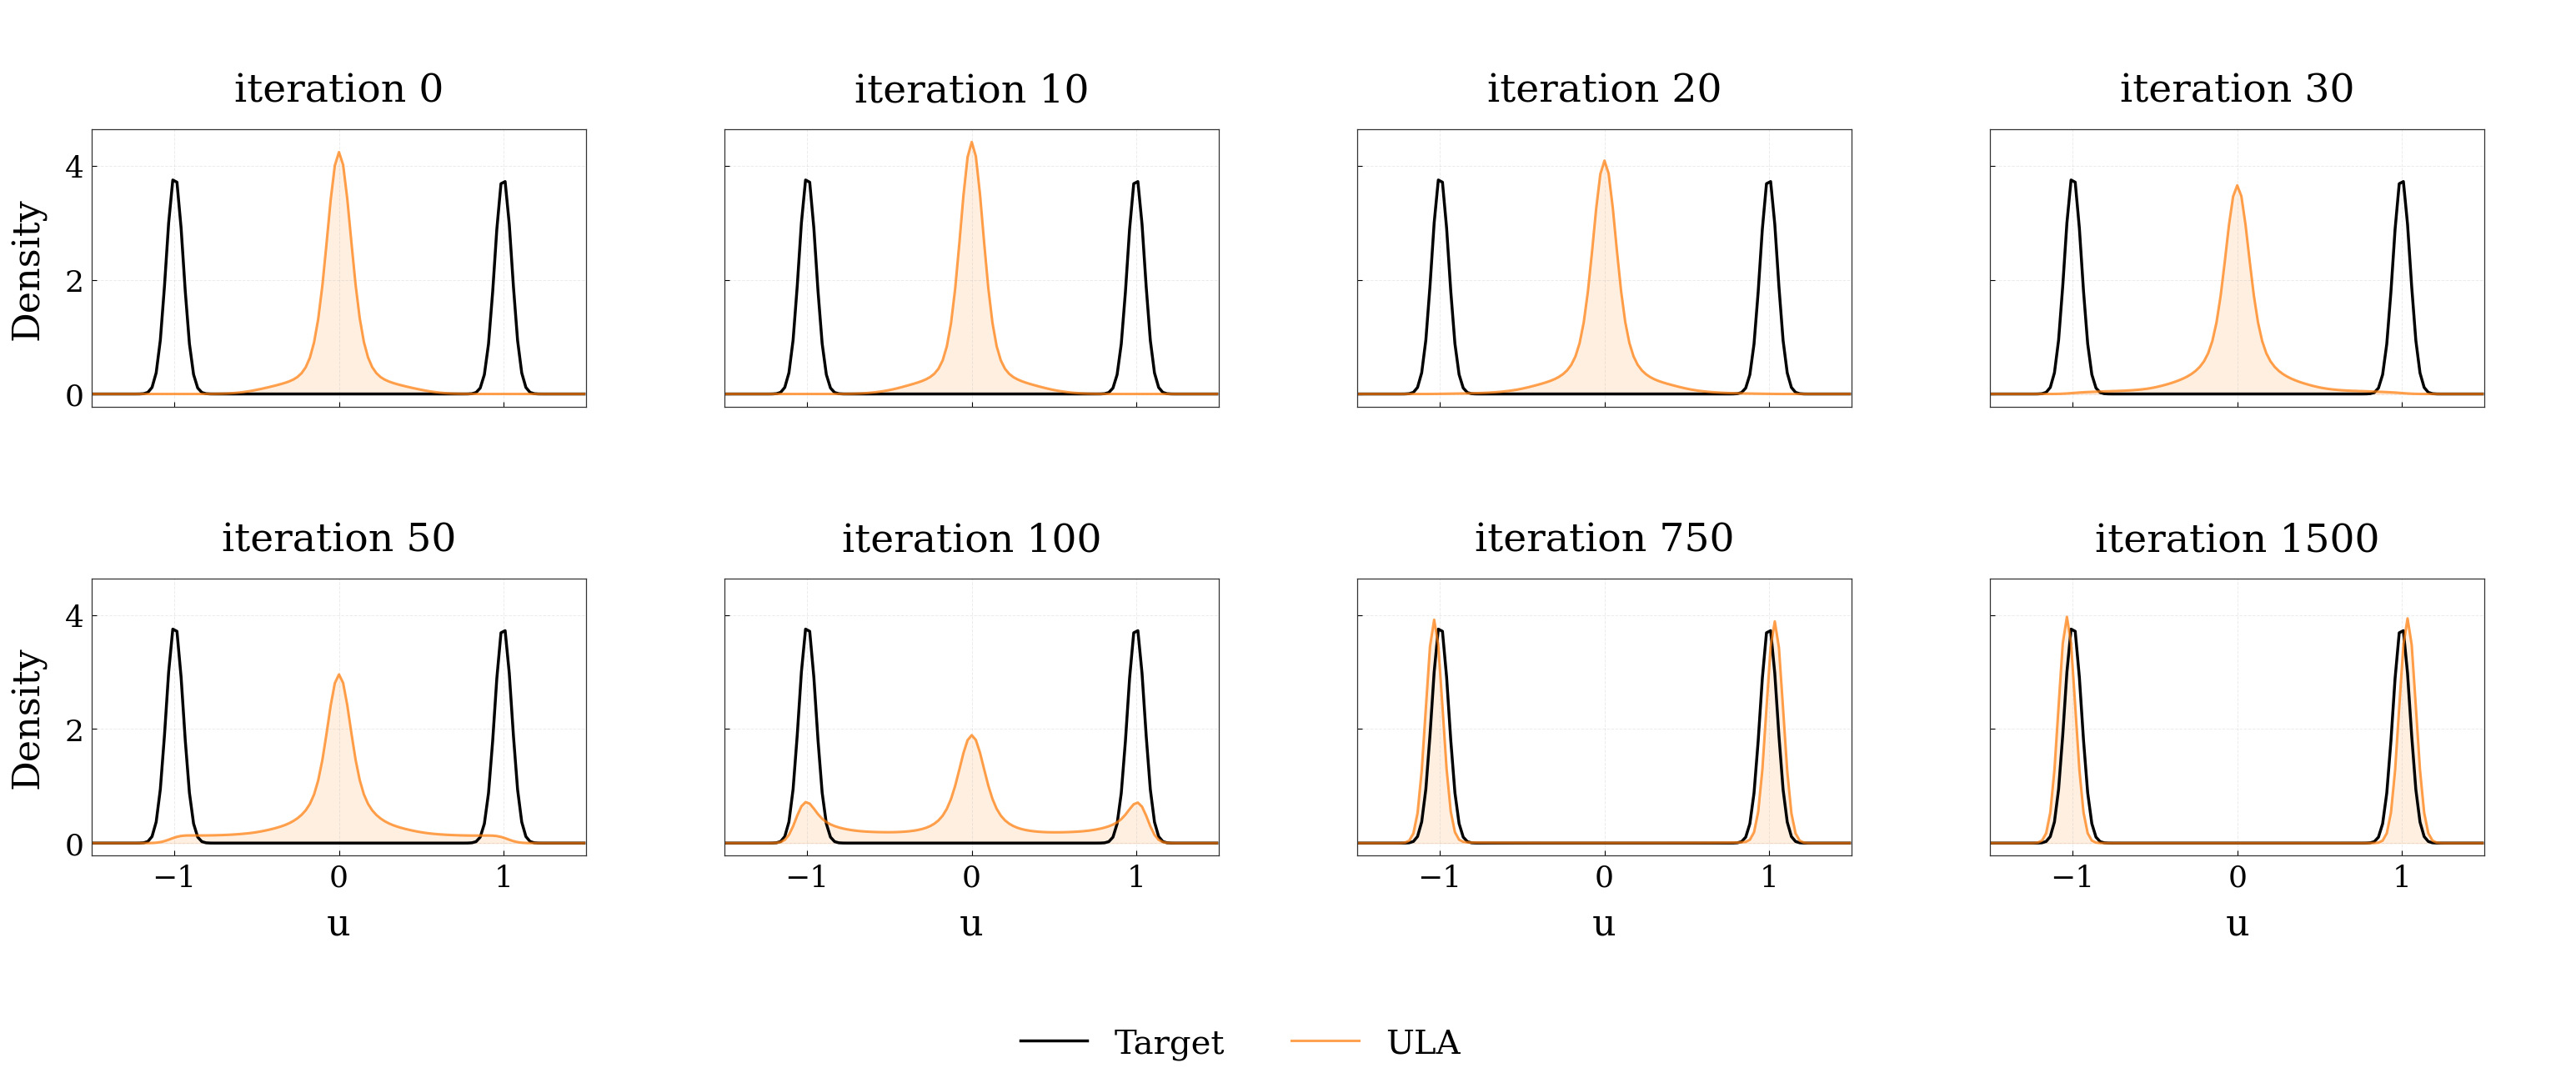

Caption: Pixel-value distributions over iterations for ULA at Allen-Cahn noise sigma=1.4142.
Saved: figures\allen_cahn\test_3_allen_cahn_baseline_sigma_1.4142_ula_timeline.png and figures\allen_cahn\test_3_allen_cahn_baseline_sigma_1.4142_ula_timeline.pdf


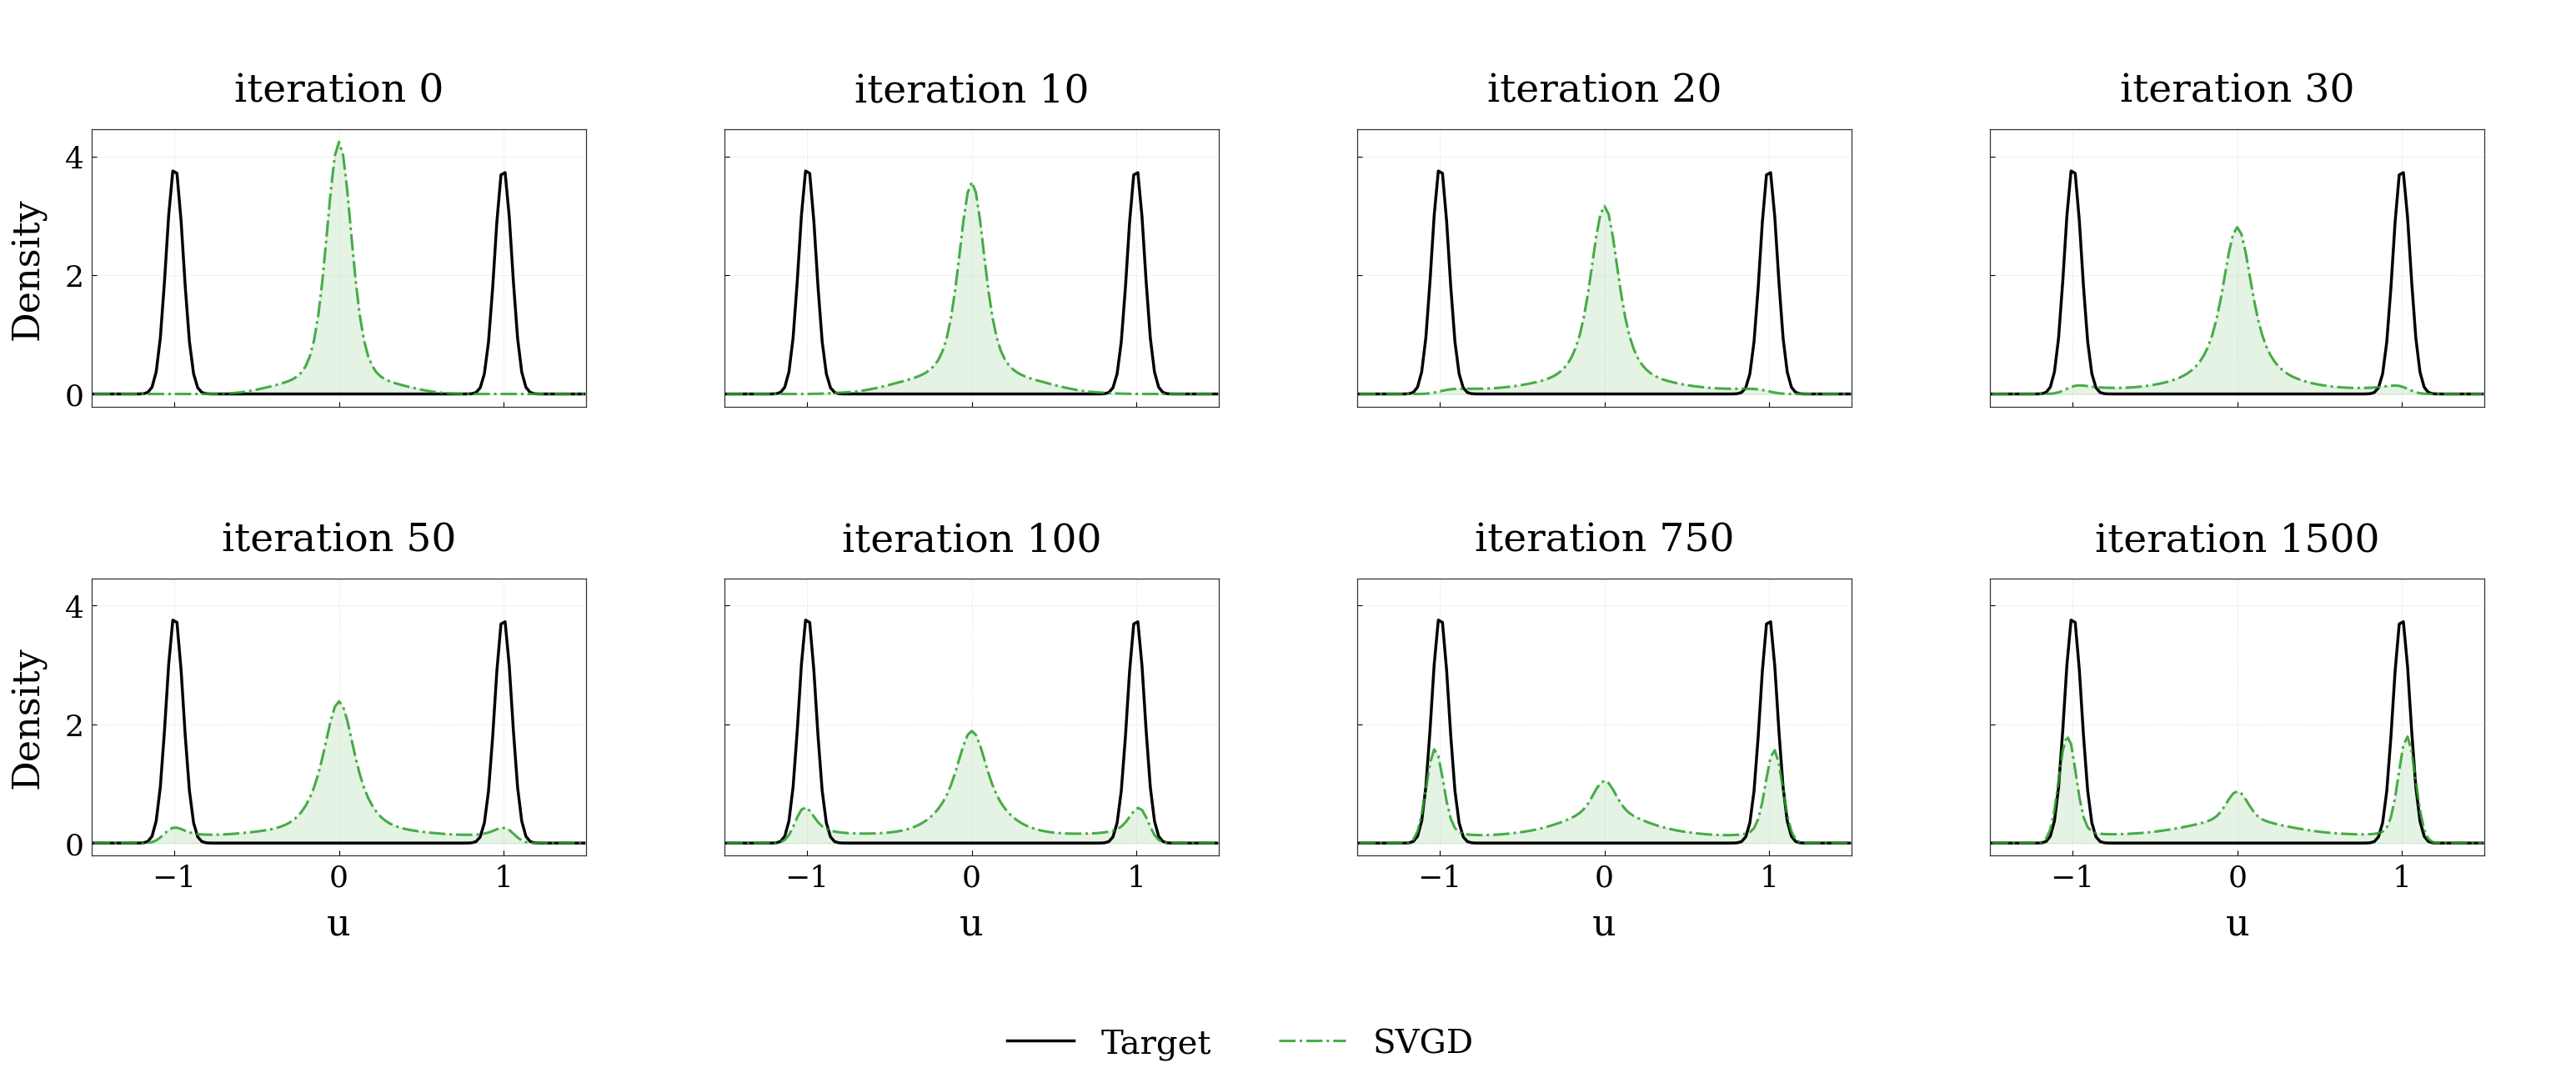

Caption: Pixel-value distributions over iterations for SVGD at Allen-Cahn noise sigma=1.4142.
Saved: figures\allen_cahn\test_3_allen_cahn_baseline_sigma_1.4142_svgd_timeline.png and figures\allen_cahn\test_3_allen_cahn_baseline_sigma_1.4142_svgd_timeline.pdf


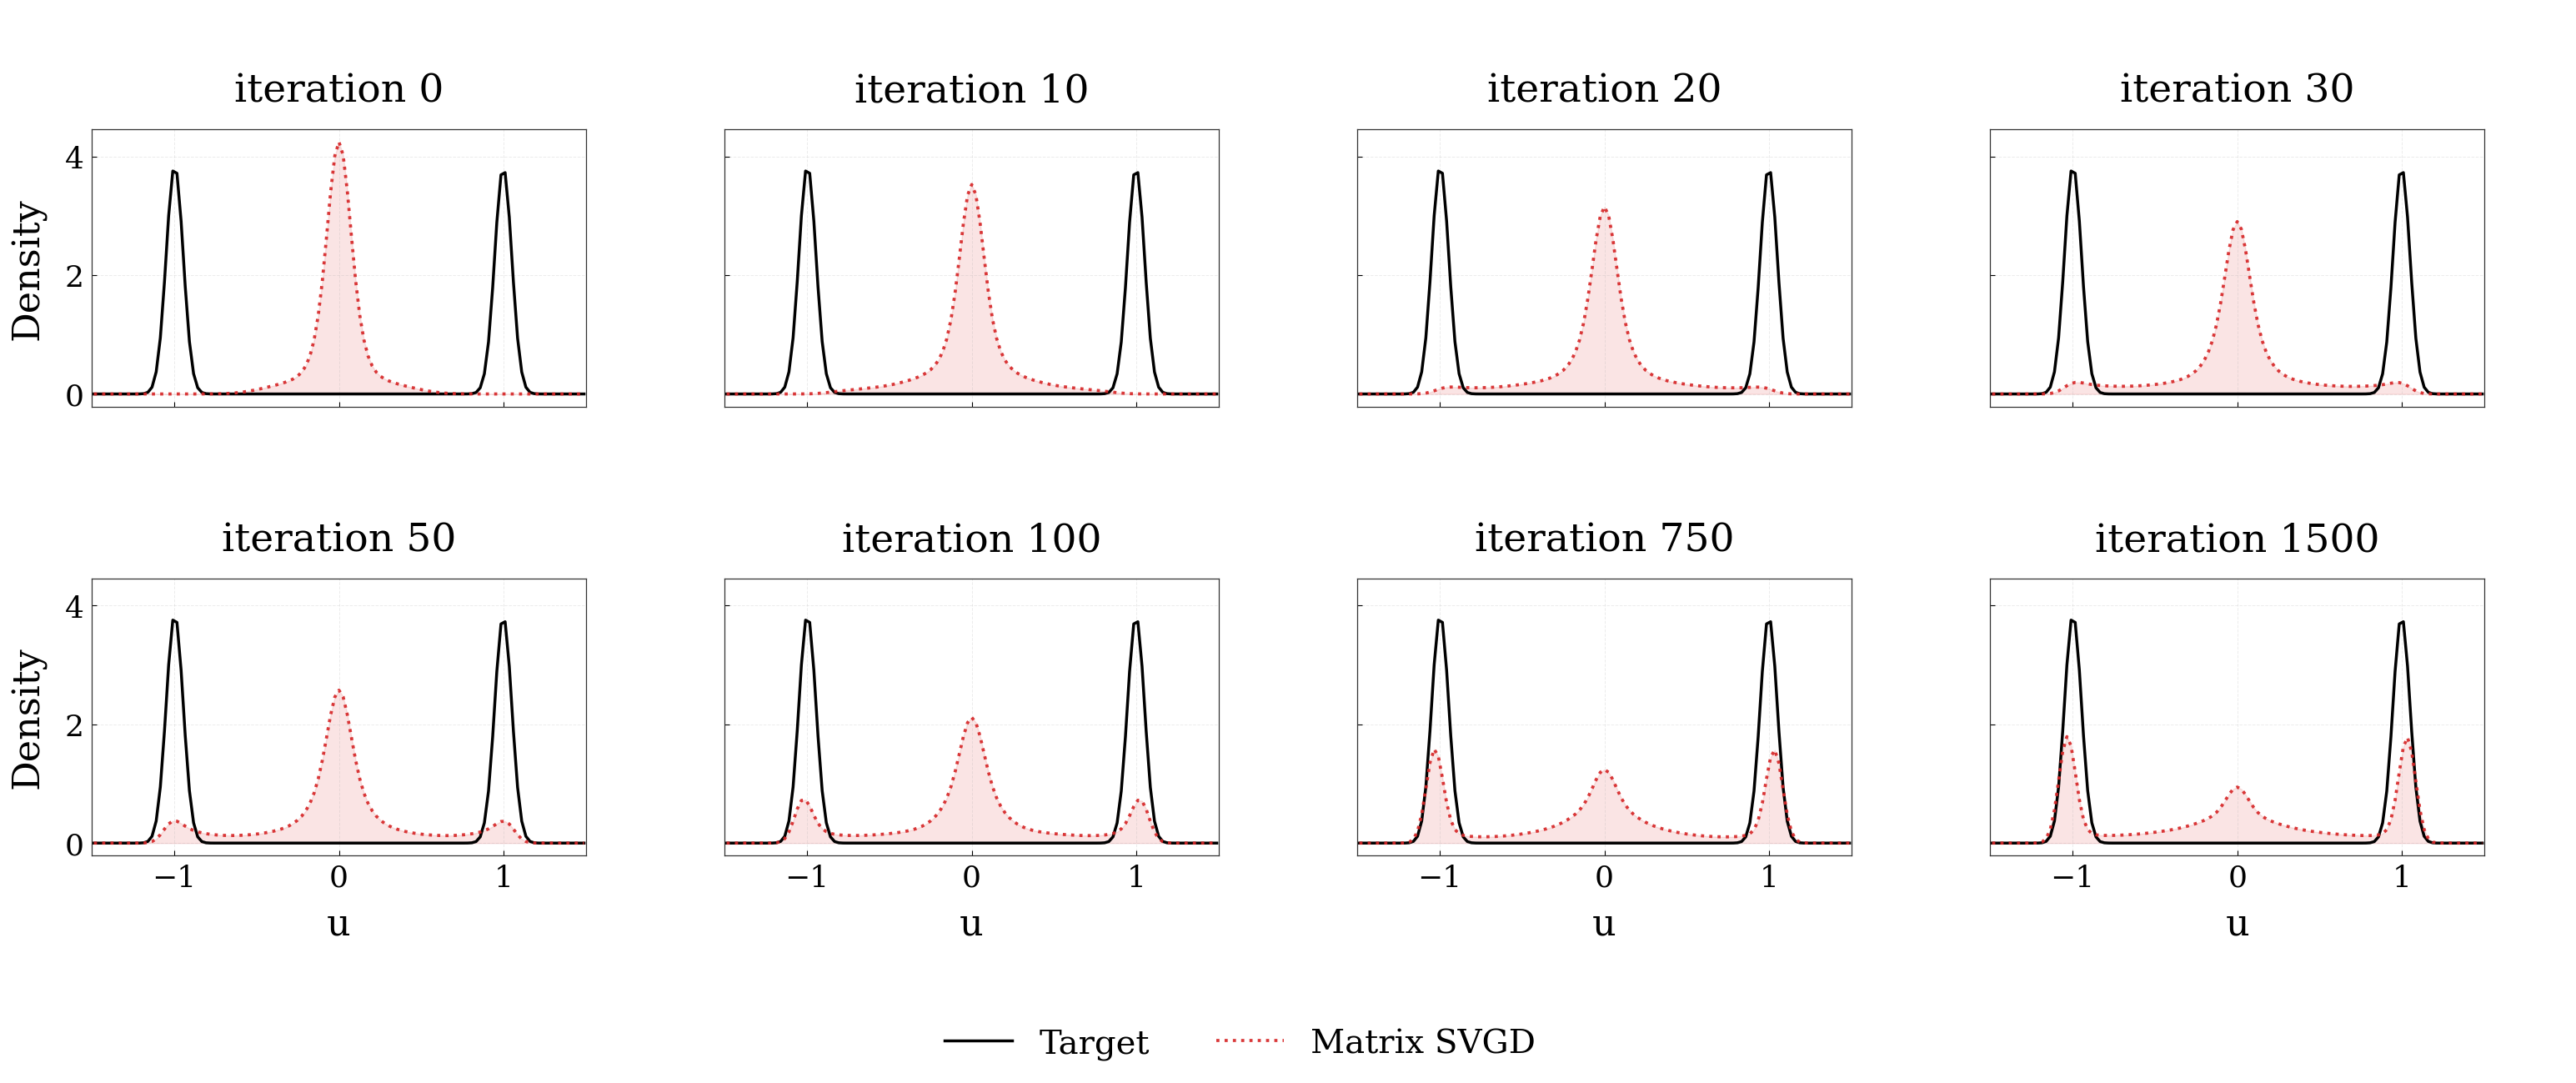

Caption: Pixel-value distributions over iterations for Matrix SVGD at Allen-Cahn noise sigma=1.4142.
Saved: figures\allen_cahn\test_3_allen_cahn_baseline_sigma_1.4142_matrix_svgd_timeline.png and figures\allen_cahn\test_3_allen_cahn_baseline_sigma_1.4142_matrix_svgd_timeline.pdf


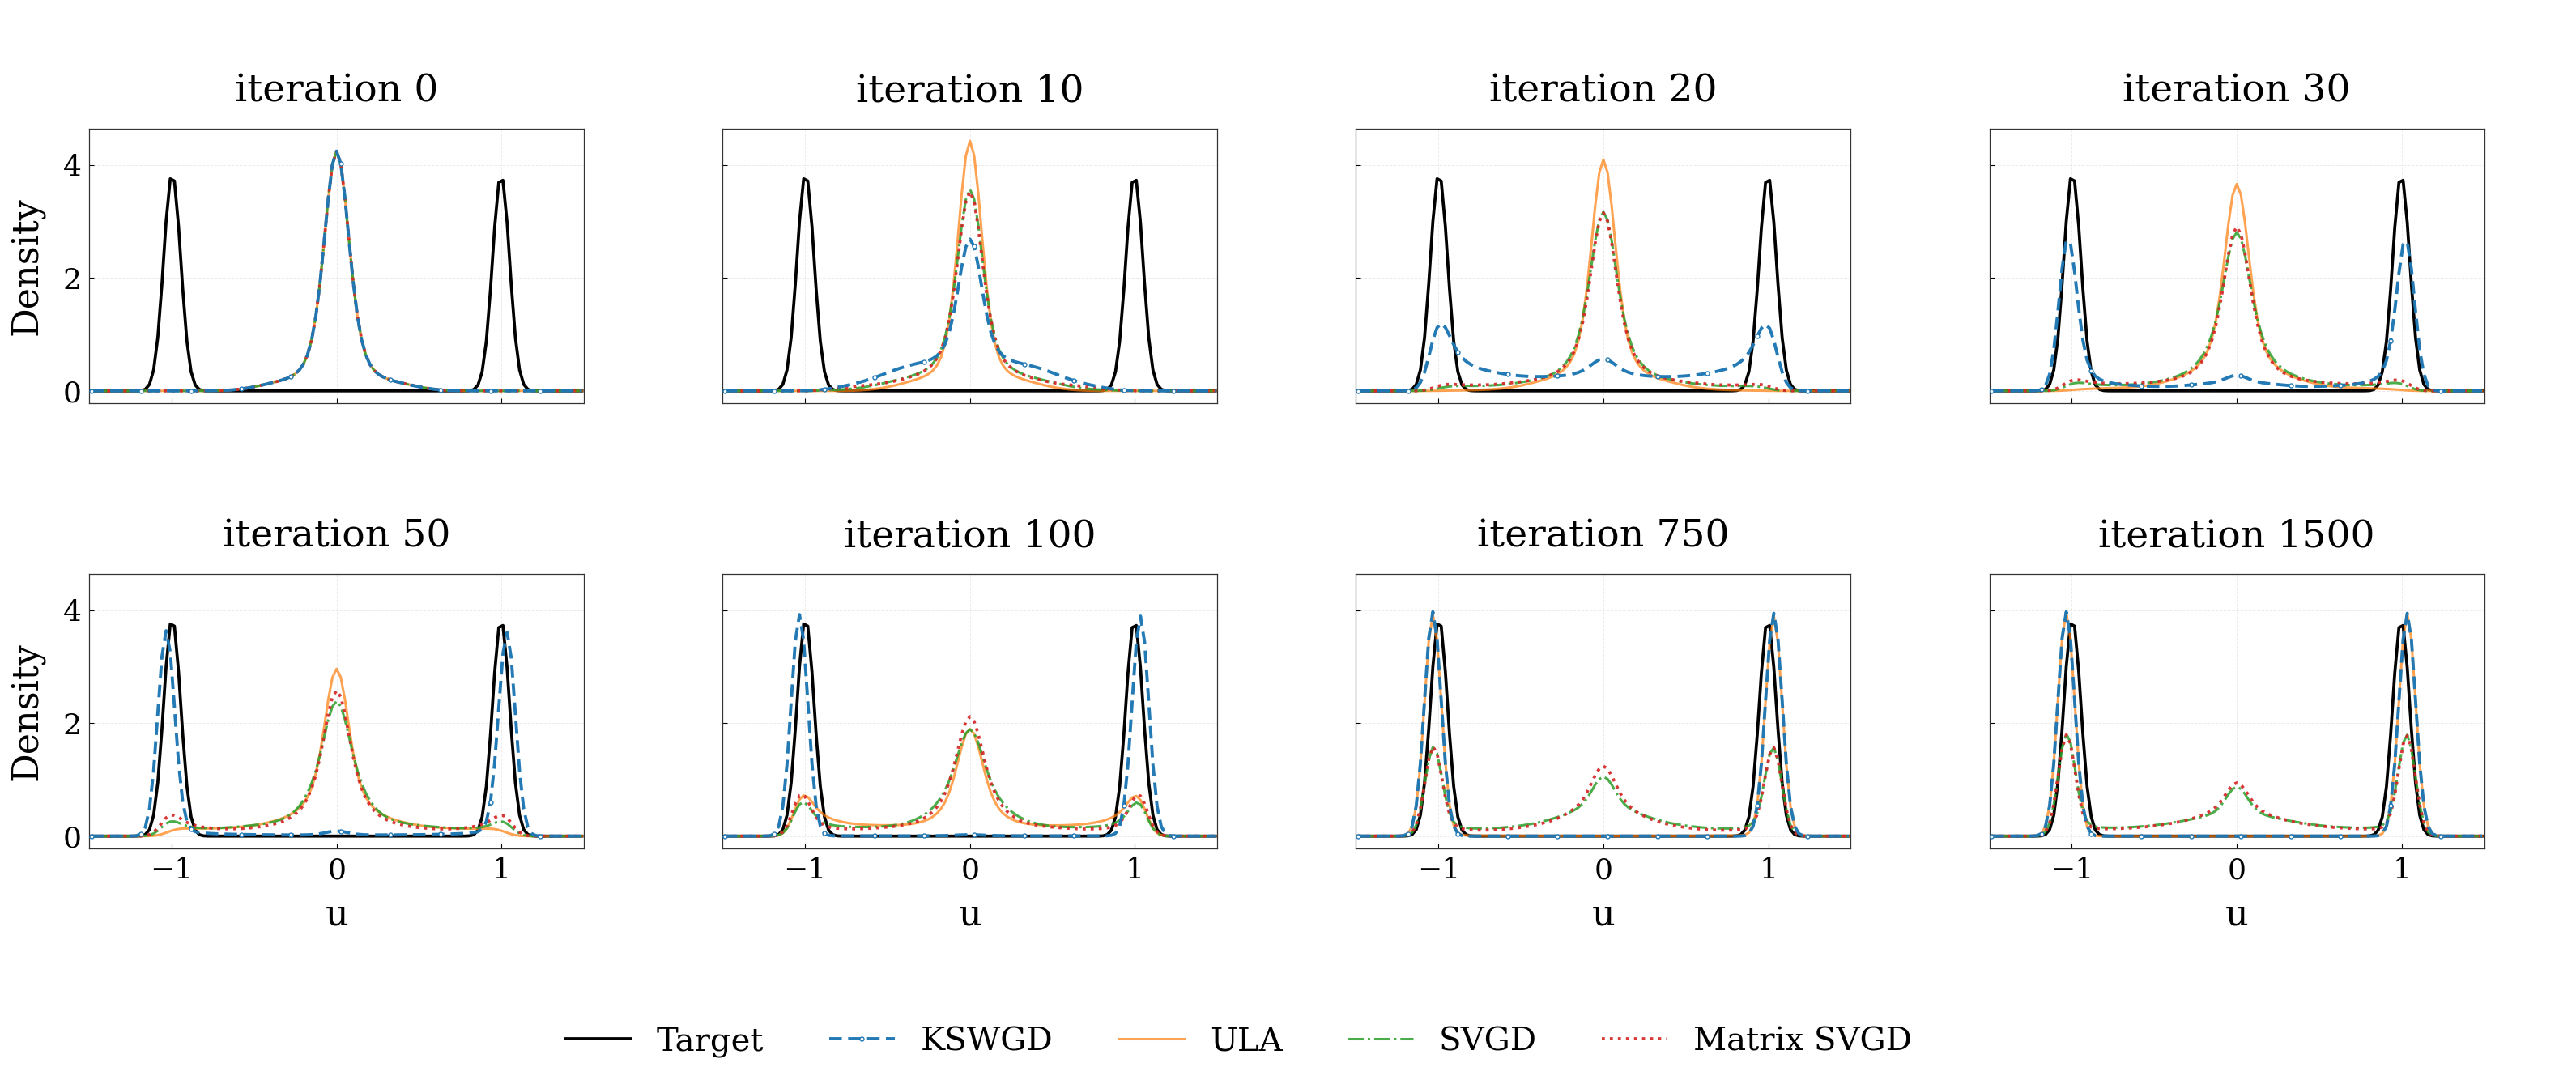

Caption: Pixel-value distributions over iterations for all baseline methods at Allen-Cahn noise sigma=1.4142.
Saved: figures\allen_cahn\test_3_allen_cahn_baseline_sigma_1.4142_method_timeline_overlay.png and figures\allen_cahn\test_3_allen_cahn_baseline_sigma_1.4142_method_timeline_overlay.pdf


In [3]:
DISPLAY_SIGMA = 1.4142
item = results[DISPLAY_SIGMA]
field_rows = {'Target': item['target_fields'][:4]}
for name, arr in item['decoded_final'].items():
    field_rows[name] = arr[:4]
plot_ac_field_grid(
    field_rows,
    stem=f'figures/allen_cahn/test_3_allen_cahn_baseline_sigma_{DISPLAY_SIGMA:g}_fields',
    caption=f'Decoded Allen-Cahn field samples for KSWGD and baselines at noise sigma={DISPLAY_SIGMA:g}.',
)
for method in ['KSWGD', 'ULA', 'SVGD', 'Matrix SVGD']:
    plot_ac_histogram_timeline(
        item['target_fields'], item['decoded_by_method_step'][method],
        method=method,
        stem=f"figures/allen_cahn/test_3_allen_cahn_baseline_sigma_{DISPLAY_SIGMA:g}_{method.lower().replace(' ', '_')}_timeline",
        caption=f'Pixel-value distributions over iterations for {method} at Allen-Cahn noise sigma={DISPLAY_SIGMA:g}.',
    )
plot_ac_method_timeline_overlay(
    item['target_fields'], item['decoded_by_method_step'],
    stem=f'figures/allen_cahn/test_3_allen_cahn_baseline_sigma_{DISPLAY_SIGMA:g}_method_timeline_overlay',
    caption=f'Pixel-value distributions over iterations for all baseline methods at Allen-Cahn noise sigma={DISPLAY_SIGMA:g}.',
)
